<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/_drone_delivery_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🚁 Session 4 — Decision Trees & Random Forests
## SkyDrop Logistics: Drone Delivery Risk Assessment



**SkyDrop Logistics** runs a fleet of delivery drones in a mid-sized city.
Before every flight, an automated system must decide the **risk level** of
that delivery:

- 🟢 **Low** — dispatch as planned
- 🟡 **Medium** — dispatch with extra monitoring
- 🔴 **High** — reroute, delay, or cancel the flight

This is a **classification problem** (not regression) because the business
doesn't need an exact risk number — it needs a *decision category* that
triggers a specific operational response. Get it wrong, and SkyDrop either
grounds drones unnecessarily (lost revenue) or dispatches a drone into a
dangerous flight (safety incident, damaged cargo, angry customer).





## 1. Setup — Import Libraries

We only import what we actually need: `numpy`/`pandas` for data,
`matplotlib` for plotting, and `scikit-learn` for modeling. We also
silence a few noisy (but harmless) warnings so the notebook stays readable.


In [1]:

# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling & evaluation (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score
)

# Warnings: sklearn/pandas sometimes print convergence or future-behavior
# warnings that are safe to ignore in a teaching context.
import warnings
warnings.filterwarnings("ignore")

# Make plots a bit bigger and easier to read by default
plt.rcParams["figure.figsize"] = (8, 5)

# For fully reproducible results across the whole notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving drone_delivery_risk.csv to drone_delivery_risk.csv



## 2. Load the Dataset




In [3]:
df = pd.read_csv("drone_delivery_risk.csv")
df.shape


(3000, 22)

In [4]:

# First look at the data
df.head()


,flight_id,distance_km,battery_level_pct,temperature_c,humidity_pct,wind_speed_kmh,payload_weight_kg,altitude_m,pilot_experience_years,traffic_density_index,...,drone_type,delivery_zone,is_weekend,night_flight,gps_signal_lost,restricted_airspace_clearance,operator_certification_level,traffic_level,risk_score_hidden,risk_level
0,FL101801,2.77,92.9,45.0,89.6,5.0,2.06,103.9,0.0,43.4,...,Quadcopter,Suburban,False,False,False,True,Advanced,Low,-0.74,Low
1,FL101190,7.34,73.5,19.2,67.6,11.8,1.76,73.8,6.0,54.9,...,Hexacopter,Suburban,False,False,False,False,Basic,Medium,3.31,Low
2,FL101817,5.99,96.8,35.3,25.7,11.9,3.63,80.2,3.1,54.3,...,Quadcopter,Suburban,True,True,False,False,Basic,Medium,7.33,Low
3,FL100251,1.01,47.6,27.4,79.1,8.6,0.80,139.2,2.8,51.4,...,Quadcopter,Urban,False,False,False,False,Expert,Medium,8.66,Medium
4,FL102505,0.94,73.1,37.7,46.8,11.8,3.13,89.7,2.1,76.0,...,Quadcopter,Rural,True,True,False,False,Basic,High,6.12,Low


In [5]:

# Shape: how many flights (rows) and features (columns) do we have?
print(f"Rows (flights):    {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")


Rows (flights):    3000
Columns (features): 22


In [6]:

# Data types — notice we have a genuine MIX of feature types:
# numeric, categorical (text), boolean (True/False), and ordinal (ordered categories)
df.dtypes


,0
flight_id,object
distance_km,float64
battery_level_pct,float64
temperature_c,float64
humidity_pct,float64
wind_speed_kmh,float64
payload_weight_kg,float64
altitude_m,float64
pilot_experience_years,float64
traffic_density_index,float64



### 📋 What's in this dataset?

| Column | Type | Meaning |
|---|---|---|
| `flight_id` | ID | Unique flight identifier (not a feature — drop before modeling) |
| `distance_km` | Numeric | Route distance in kilometers |
| `battery_level_pct` | Numeric | Battery % at dispatch (contains a few impossible >100% sensor glitches — outliers!) |
| `temperature_c` | Numeric | Ambient temperature (contains a few impossible sub-zero glitches — outliers!) |
| `humidity_pct` | Numeric | Relative humidity % (has some missing values) |
| `wind_speed_kmh` | Numeric | Wind speed |
| `payload_weight_kg` | Numeric | Parcel weight (contains a few "40-90kg" data-entry-mistake outliers) |
| `altitude_m` | Numeric | Cruise altitude — mostly a **weak predictor** |
| `pilot_experience_years` | Numeric | Remote operator's experience (has some missing values) |
| `traffic_density_index` | Numeric | Airspace congestion score, 0–100 |
| `sensor_reading` | Numeric | Raw onboard sensor value — mostly **noise**, with glitch outliers |
| `weather_condition` | Categorical | Clear / Cloudy / Rainy / Foggy / Windy / Stormy |
| `drone_type` | Categorical | Quadcopter / Hexacopter / FixedWing |
| `delivery_zone` | Categorical | Urban / Suburban / Rural / Restricted |
| `is_weekend` | Boolean | Weekend flight? |
| `night_flight` | Boolean | Flight after dark? |
| `gps_signal_lost` | Boolean | Did the drone report GPS signal loss? |
| `restricted_airspace_clearance` | Boolean | Cleared for restricted airspace? |
| `operator_certification_level` | Ordinal | Basic < Advanced < Expert |
| `traffic_level` | Ordinal | Low < Medium < High |
| `risk_score_hidden` | Numeric | The internal continuous score used to build the target (instructor reference only — **drop before modeling**, this would be cheating!) |
| `risk_level` | **Target** | Low / Medium / High — what we're predicting |

> ⚠️ **Important:** `risk_score_hidden` is only included so instructors can
> explain how the target was built. If you leave it in your feature set,
> your model will "cheat" and get suspiciously perfect accuracy — this is
> called **data leakage**, and we will explicitly drop it before training.



## 3. Exploratory Data Analysis (EDA)

Before modeling anything, we look at the data. EDA answers questions like:
*Is anything missing? Is the target balanced? Do features look reasonable,
or do we already see something suspicious (hello, outliers)?*


In [7]:

# Missing values per column
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)


Columns with missing values:
humidity_pct              45
pilot_experience_years    45
sensor_reading            45
dtype: int64



We have a small amount of missing data in three columns. This is
intentional and realistic — sensors don't always report, and forms don't
always get filled out completely. We'll handle this later, right before
modeling.


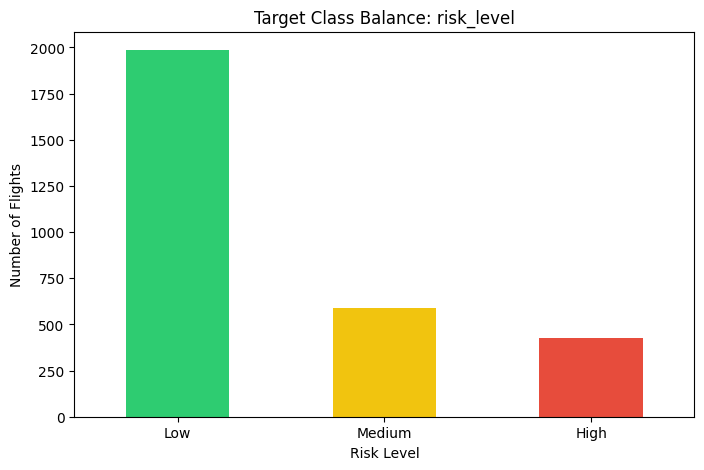

risk_level
Low       66.2
Medium    19.6
High      14.2
Name: proportion, dtype: float64


In [8]:

# Target class balance
class_counts = df["risk_level"].value_counts()
class_pct = df["risk_level"].value_counts(normalize=True).round(3) * 100

fig, ax = plt.subplots()
class_counts.reindex(["Low", "Medium", "High"]).plot(kind="bar", color=["#2ecc71", "#f1c40f", "#e74c3c"], ax=ax)
ax.set_title("Target Class Balance: risk_level")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.show()

print(class_pct)



The classes are **imbalanced** (most flights are "Low" risk — which makes
sense, most days are fine!). Keep this in mind: accuracy alone can be
misleading on imbalanced data, which is exactly why we'll also look at
precision, recall, and F1-score later, broken down **per class**.


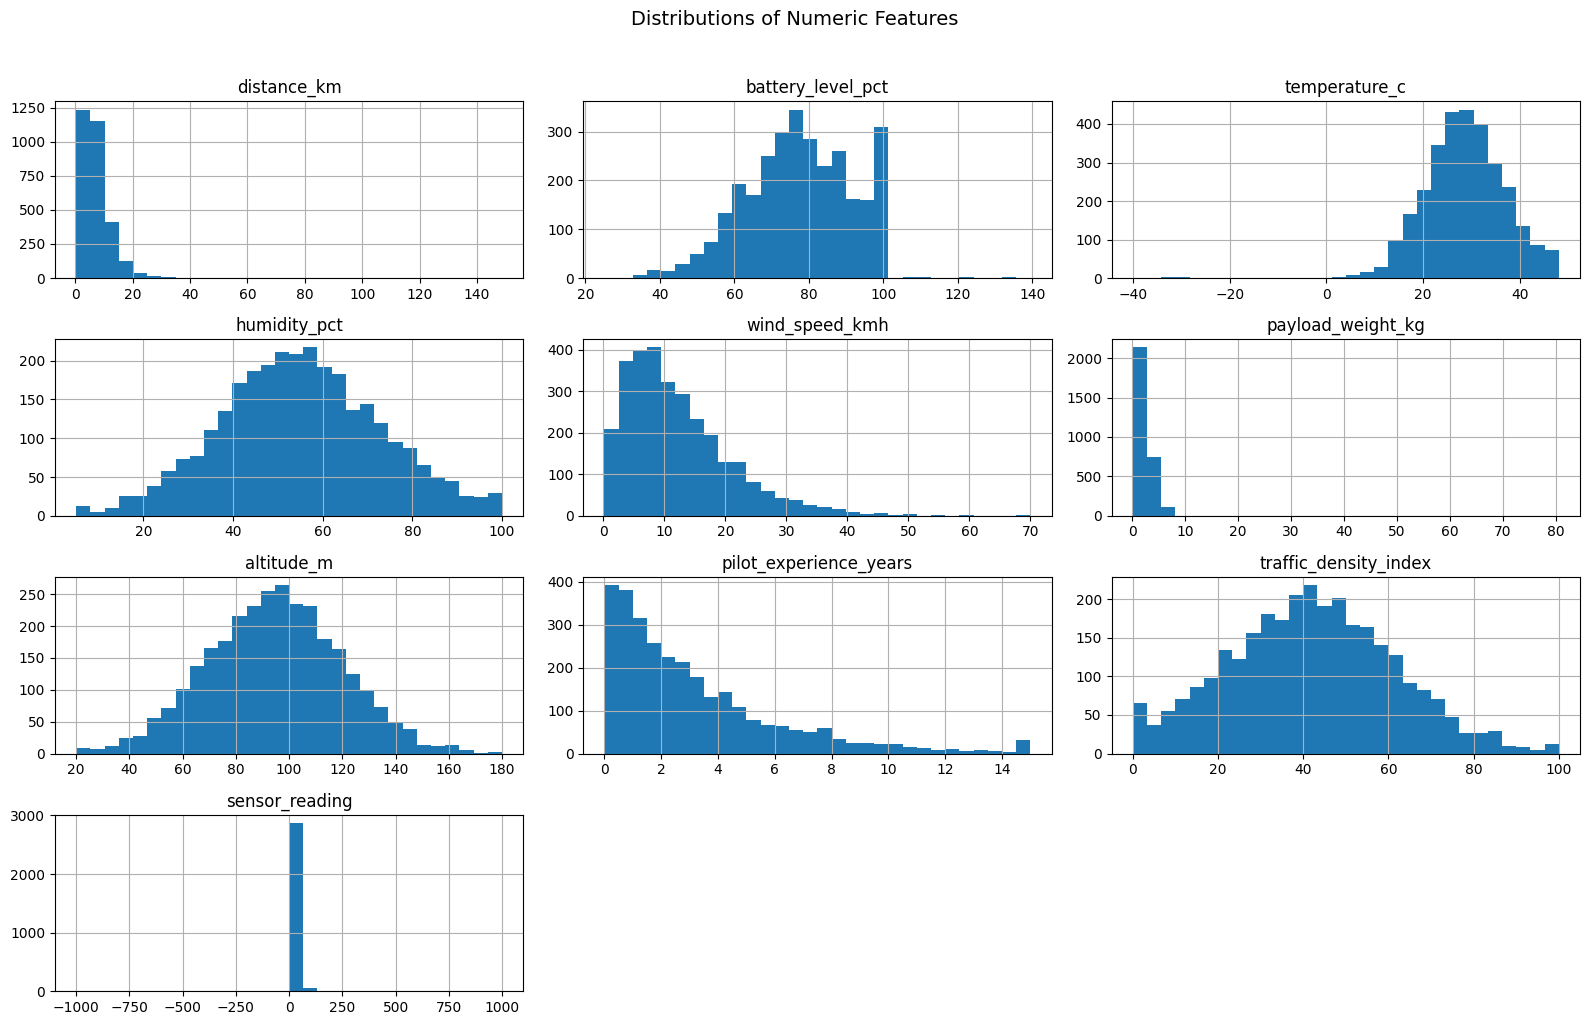

In [9]:

# Histograms of the numeric features — shape, skew, and (hint) outliers
numeric_cols = [
    "distance_km", "battery_level_pct", "temperature_c", "humidity_pct",
    "wind_speed_kmh", "payload_weight_kg", "altitude_m",
    "pilot_experience_years", "traffic_density_index", "sensor_reading"
]

df[numeric_cols].hist(figsize=(16, 10), bins=30)
plt.suptitle("Distributions of Numeric Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



Look closely at `battery_level_pct` (values above 100%!), `temperature_c`
(a few sub-zero bars in a city that rarely freezes), `payload_weight_kg`
(a handful of 40–90kg "parcels" — no delivery drone carries that), and
`sensor_reading` (extreme spikes far from the main cluster). These are our
**intentionally injected outliers** — keep them in mind, we'll formally
detect them in Section 5.


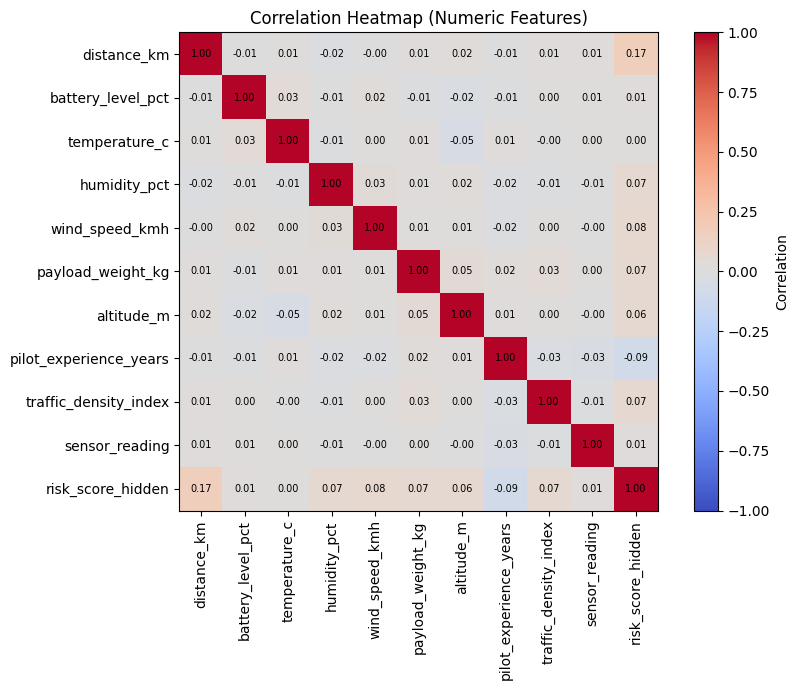

In [10]:

# Correlation heatmap for numeric features (helps spot linear relationships
# and redundant features — but remember, correlation only captures LINEAR
# relationships, which is a limitation we'll come back to!)
corr = df[numeric_cols + ["risk_score_hidden"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()



Notice how **weak** most of these correlations look, even for features we
know matter (like `distance_km` or `battery_level_pct`)! That's because
their real relationship with risk is **nonlinear** — a simple correlation
coefficient measures *straight-line* relationships and completely misses
threshold effects and interactions. Keep this observation in your pocket;
we'll prove it visually in Section 5 and again when we compare Logistic
Regression to tree-based models.


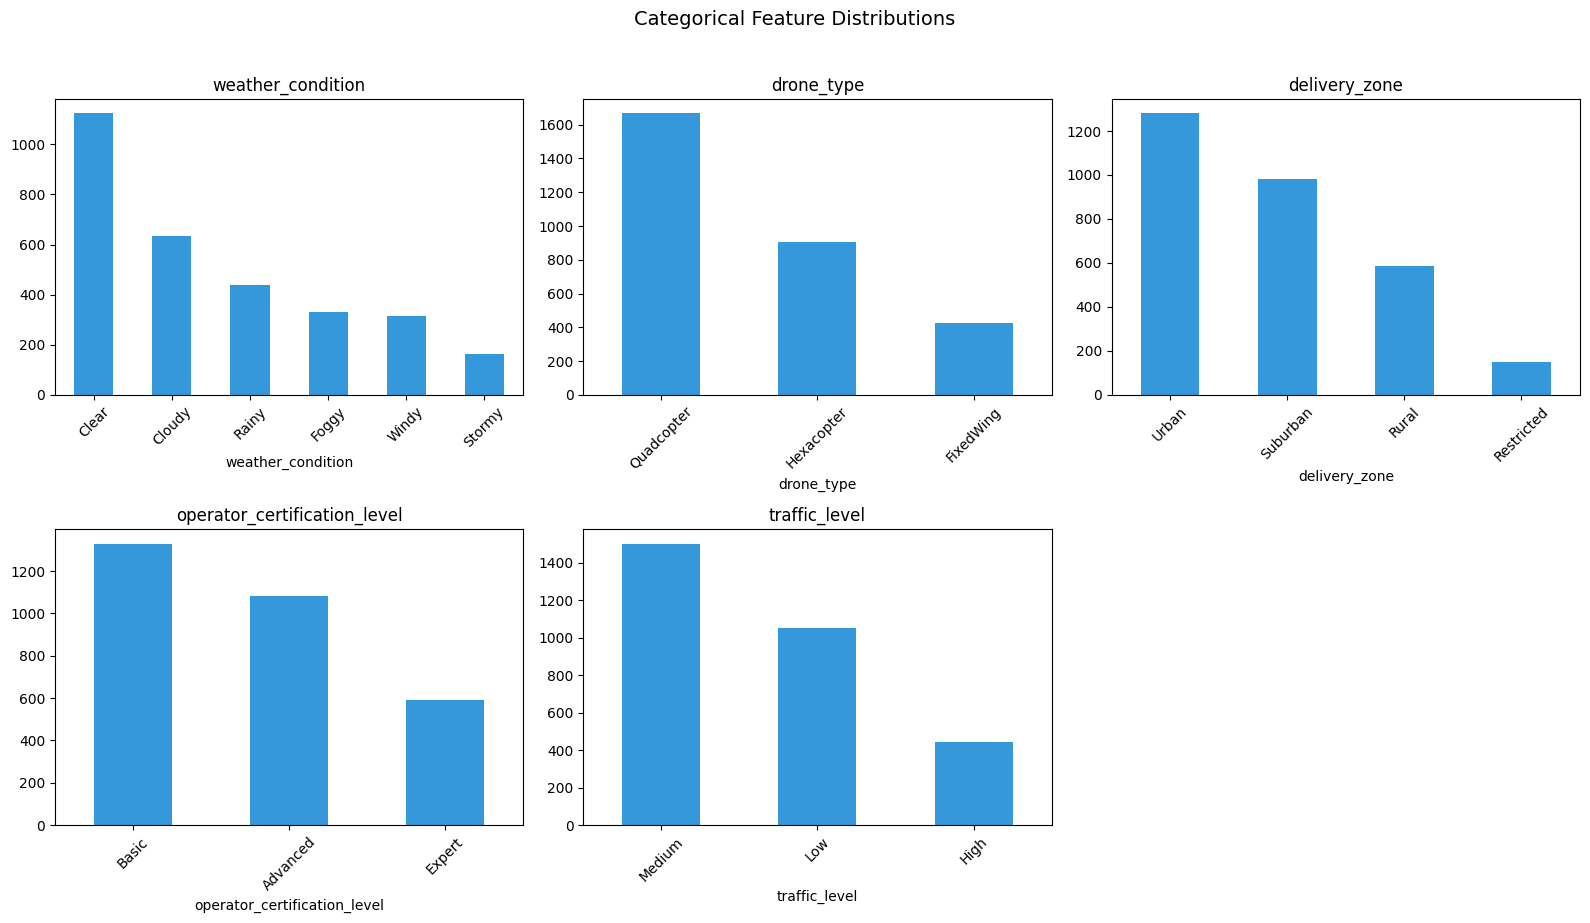

In [11]:

# Categorical feature distributions
categorical_cols = ["weather_condition", "drone_type", "delivery_zone", "operator_certification_level", "traffic_level"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color="#3498db")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)
axes[-1].axis("off")  # unused subplot
plt.suptitle("Categorical Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


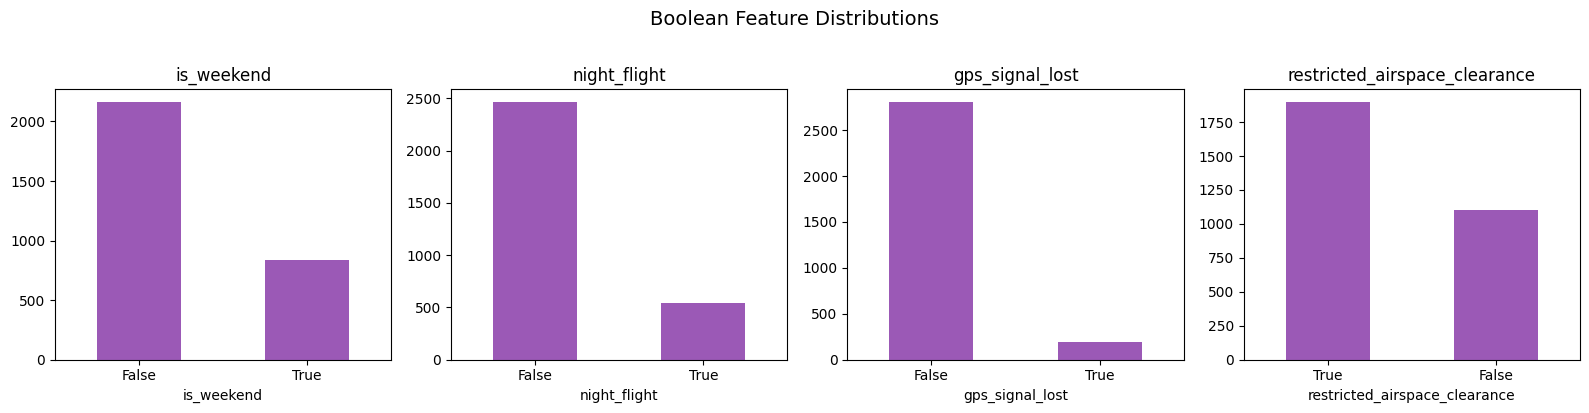

In [12]:

# Boolean feature distributions
bool_cols = ["is_weekend", "night_flight", "gps_signal_lost", "restricted_airspace_clearance"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(bool_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color="#9b59b6")
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=0)
plt.suptitle("Boolean Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



## 4. Outlier Analysis — "Should We Always Remove Outliers?"

**This is one of the most common beginner questions, so let's slow down.**

> **What is an outlier?**
> A data point that is unusually far from the rest of the data for that
> feature. It might be a genuine (if rare) event, a data entry mistake, or
> a sensor malfunction. Not all outliers are "bad data" — some are the
> most important rows in your dataset (e.g., in fraud detection, the fraud
> *is* the outlier!).

We'll detect outliers formally using the **IQR (Interquartile Range)
method**:

- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Anything below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as an outlier

Then — instead of just deleting them because "that's what you're supposed
to do" — we'll **run the experiment**: train models with and without the
outliers removed, and actually compare the results.


In [13]:

def iqr_outlier_mask(series, k=1.5):
    # Return a boolean mask marking IQR-based outliers in a numeric Series.
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

# Detect outliers across all numeric columns
outlier_summary = {}
combined_outlier_mask = pd.Series(False, index=df.index)

for col in numeric_cols:
    mask = iqr_outlier_mask(df[col])
    outlier_summary[col] = mask.sum()
    combined_outlier_mask |= mask.fillna(False)

outlier_summary = pd.Series(outlier_summary).sort_values(ascending=False)
print("Outliers detected per column (IQR method):")
print(outlier_summary)
print(f"\nTotal rows flagged as an outlier in AT LEAST ONE column: {combined_outlier_mask.sum()} "
      f"out of {len(df)} ({combined_outlier_mask.mean()*100:.1f}%)")


Outliers detected per column (IQR method):
pilot_experience_years    144
distance_km               119
payload_weight_kg         105
wind_speed_kmh             92
sensor_reading             37
altitude_m                 24
battery_level_pct          21
temperature_c              20
traffic_density_index      14
humidity_pct               11
dtype: int64

Total rows flagged as an outlier in AT LEAST ONE column: 555 out of 3000 (18.5%)



### 🤔 Should we remove them?

There's no universal answer — it depends on **why** the outlier exists:

- If it's a **data entry / sensor error** (like `battery_level_pct` > 100%,
  or `temperature_c` of -35°C in a city that never freezes) — it's
  probably safe, even correct, to fix or remove it.
- If it's a **genuine rare event** (a real long-haul 150km test flight) —
  removing it might throw away real signal the model needs to learn from.

Rather than guessing, let's **test it**: we'll train the same models on
(a) the full data, and (b) the data with flagged outliers removed, and
compare accuracy. We'll do this again later for Decision Trees and Random
Forests specifically, since tree-based models are famously more robust to
outliers than linear models — let's prove that instead of just stating it.


In [14]:

# Build a "clean" version of the dataframe with outlier rows removed, so we
# can compare later. We keep both `df` (full) and `df_clean` (outliers removed).
df_clean = df.loc[~combined_outlier_mask].copy()
print(f"Full dataset:    {df.shape[0]} rows")
print(f"Outliers removed: {df_clean.shape[0]} rows ({df.shape[0] - df_clean.shape[0]} rows dropped)")


Full dataset:    3000 rows
Outliers removed: 2445 rows (555 rows dropped)



## 5. What Does "Non-Linearity" Actually Mean?

> **Linear relationship:** as X goes up, Y changes at a *constant rate*,
> in a straight line, everywhere. Logistic Regression is fundamentally a
> **linear model** — it draws straight-line-like decision boundaries
> (technically, a straight *hyperplane* in feature space).
>
> **Non-linear relationship:** the effect of X on Y *changes* depending on
> the value of X, or depending on some *other* feature entirely. Real
> business data is full of this.

This dataset was **deliberately built with several nonlinear rules**.
Let's visualize each one directly, so "non-linearity" stops being an
abstract word and becomes something you can literally see on a chart.


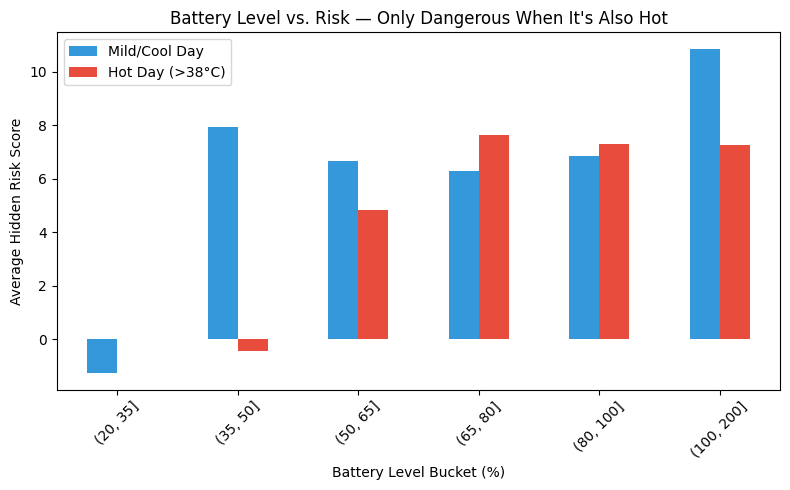

In [15]:

# Rule: Battery only matters when it's ALSO hot.
# We show average risk by battery bucket, separately for hot vs. mild days.
plot_df = df.copy()
plot_df["battery_bucket"] = pd.cut(plot_df["battery_level_pct"], bins=[0, 20, 35, 50, 65, 80, 100, 200])
plot_df["is_hot"] = plot_df["temperature_c"] > 38

pivot = plot_df.groupby(["battery_bucket", "is_hot"], observed=True)["risk_score_hidden"].mean().unstack()

fig, ax = plt.subplots()
pivot.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Battery Level vs. Risk — Only Dangerous When It's Also Hot")
ax.set_xlabel("Battery Level Bucket (%)")
ax.set_ylabel("Average Hidden Risk Score")
ax.legend(["Mild/Cool Day", "Hot Day (>38°C)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Notice the **hot-day (red) line only spikes at low battery** — on mild
days, low battery barely matters. A single straight line (what Logistic
Regression effectively draws) cannot represent "this feature matters, but
*only* in combination with that other feature." A tree can — it just adds
**two splits** instead of one.


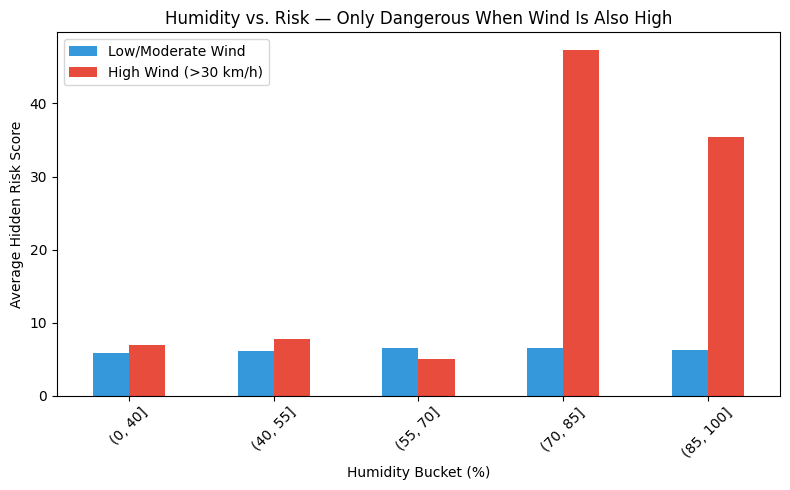

In [16]:

# Rule: Humidity only matters when wind is also high (storm-like conditions)
plot_df["humid_bucket"] = pd.cut(plot_df["humidity_pct"], bins=[0, 40, 55, 70, 85, 100])
plot_df["high_wind"] = plot_df["wind_speed_kmh"] > 30

pivot2 = plot_df.groupby(["humid_bucket", "high_wind"], observed=True)["risk_score_hidden"].mean().unstack()

fig, ax = plt.subplots()
pivot2.plot(kind="bar", ax=ax, color=["#3498db", "#e74c3c"])
ax.set_title("Humidity vs. Risk — Only Dangerous When Wind Is Also High")
ax.set_xlabel("Humidity Bucket (%)")
ax.set_ylabel("Average Hidden Risk Score")
ax.legend(["Low/Moderate Wind", "High Wind (>30 km/h)"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 6. Encoding Categorical Features

Machine learning models need numbers, not text. We have two common
encoding strategies:

- **One-Hot Encoding**: creates a new 0/1 column for each category. Best
  for **nominal** categories with no natural order (e.g., `weather_condition`:
  "Rainy" isn't "more" or "less" than "Foggy").
- **Label / Ordinal Encoding**: maps categories to integers that preserve
  a **meaningful order** (e.g., `operator_certification_level`:
  Basic=0 < Advanced=1 < Expert=2). Using one-hot here would *throw away*
  the useful "Expert is more experienced than Basic" information.

Boolean columns (`True`/`False`) are already effectively numeric (1/0), so
we just need to cast them.


In [17]:

# Work on a copy so our original df / df_clean stay untouched for reference
model_df = df.drop(columns=["flight_id", "risk_score_hidden"]).copy()

# --- Boolean columns: cast True/False to 1/0 ---
bool_cols = ["is_weekend", "night_flight", "gps_signal_lost", "restricted_airspace_clearance"]
for col in bool_cols:
    model_df[col] = model_df[col].astype(int)

# --- Ordinal columns: manual mapping so order is preserved ---
cert_order = {"Basic": 0, "Advanced": 1, "Expert": 2}
traffic_order = {"Low": 0, "Medium": 1, "High": 2}
model_df["operator_certification_level"] = model_df["operator_certification_level"].map(cert_order)
model_df["traffic_level"] = model_df["traffic_level"].map(traffic_order)

# --- Nominal columns: one-hot encoding ---
nominal_cols = ["weather_condition", "drone_type", "delivery_zone"]
model_df = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

# --- Target: label-encode Low/Medium/High -> 0/1/2 (keep the encoder to decode predictions later) ---
target_encoder = LabelEncoder()
target_encoder.fit(["Low", "Medium", "High"])  # fix the order explicitly
model_df["risk_level_encoded"] = target_encoder.transform(model_df["risk_level"])

print("Encoded feature columns:")
print([c for c in model_df.columns if c not in ("risk_level", "risk_level_encoded")])
model_df.head()


Encoded feature columns:
['distance_km', 'battery_level_pct', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'payload_weight_kg', 'altitude_m', 'pilot_experience_years', 'traffic_density_index', 'sensor_reading', 'is_weekend', 'night_flight', 'gps_signal_lost', 'restricted_airspace_clearance', 'operator_certification_level', 'traffic_level', 'weather_condition_Cloudy', 'weather_condition_Foggy', 'weather_condition_Rainy', 'weather_condition_Stormy', 'weather_condition_Windy', 'drone_type_Hexacopter', 'drone_type_Quadcopter', 'delivery_zone_Rural', 'delivery_zone_Suburban', 'delivery_zone_Urban']


,distance_km,battery_level_pct,temperature_c,humidity_pct,wind_speed_kmh,payload_weight_kg,altitude_m,pilot_experience_years,traffic_density_index,sensor_reading,...,weather_condition_Foggy,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Windy,drone_type_Hexacopter,drone_type_Quadcopter,delivery_zone_Rural,delivery_zone_Suburban,delivery_zone_Urban,risk_level_encoded
0,2.77,92.9,45.0,89.6,5.0,2.06,103.9,0.0,43.4,42.00,...,False,False,False,False,False,True,False,True,False,1
1,7.34,73.5,19.2,67.6,11.8,1.76,73.8,6.0,54.9,54.77,...,False,False,False,False,True,False,False,True,False,1
2,5.99,96.8,35.3,25.7,11.9,3.63,80.2,3.1,54.3,45.96,...,False,False,True,False,False,True,False,True,False,1
3,1.01,47.6,27.4,79.1,8.6,0.80,139.2,2.8,51.4,59.81,...,True,False,False,False,False,True,False,False,True,2
4,0.94,73.1,37.7,46.8,11.8,3.13,89.7,2.1,76.0,44.15,...,False,False,False,False,False,True,True,False,False,1



> 💡 One-hot encoding vs. label encoding, in one sentence: **use one-hot
> when categories have no order (don't invent a ranking), use label/ordinal
> encoding when categories genuinely do have an order (don't throw the
> ranking away).**



## 7. Handling Missing Values, then Train/Test Split

We saw earlier that `humidity_pct`, `pilot_experience_years`, and
`sensor_reading` have a small number of missing values. For this session,
we'll use a simple, transparent strategy: **fill with the median**
(robust to outliers, unlike the mean).

Then we split into **train** and **test** sets. Why split at all? Because
we need to evaluate the model on data it has genuinely never seen — that's
the only fair simulation of how it will perform on *future*, real-world
flights. If we evaluated on the same data we trained on, we'd have no way
to detect overfitting (a model that memorized the training data instead of
learning general patterns).


In [18]:

# Fill missing numeric values with the median (robust to outliers)
for col in ["humidity_pct", "pilot_experience_years", "sensor_reading"]:
    median_val = model_df[col].median()
    model_df[col] = model_df[col].fillna(median_val)

assert model_df.isna().sum().sum() == 0, "There should be no missing values left!"
print("Missing values handled. Remaining NaNs:", model_df.isna().sum().sum())


Missing values handled. Remaining NaNs: 0


In [19]:

# Separate features (X) and target (y)
feature_cols = [c for c in model_df.columns if c not in ("risk_level", "risk_level_encoded")]
X = model_df[feature_cols]
y = model_df["risk_level_encoded"]

# 80% train / 20% test, stratified so both sets keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} flights")
print(f"Test set:     {X_test.shape[0]} flights")
print("\nClass balance is preserved thanks to `stratify=y`:")
print("Train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test: ", y_test.value_counts(normalize=True).round(3).to_dict())


Training set: 2400 flights
Test set:     600 flights

Class balance is preserved thanks to `stratify=y`:
Train: {1: 0.662, 2: 0.196, 0: 0.142}
Test:  {1: 0.662, 2: 0.197, 0: 0.142}



## 8. Baseline: Logistic Regression (what you already know)

Before jumping into trees, let's set a baseline with the model from last
session. Keep this number in your head — we'll come back to it the moment
we train our first Decision Tree.


In [20]:

log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

train_acc_lr = accuracy_score(y_train, log_reg.predict(X_train))
test_acc_lr = accuracy_score(y_test, log_reg.predict(X_test))

print(f"Logistic Regression -> Train accuracy: {train_acc_lr:.3f} | Test accuracy: {test_acc_lr:.3f}")


Logistic Regression -> Train accuracy: 0.711 | Test accuracy: 0.693



Hold onto these numbers. Logistic Regression can only ever draw a straight
decision boundary between classes — so on a dataset built from threshold
effects and interactions (like ours), we expect it to leave real accuracy
on the table. Let's see if a Decision Tree can do better.



## 9. Decision Trees

### 🌳 The core idea

A Decision Tree asks a sequence of yes/no questions about your data
(`distance_km <= 14.7?`, `gps_signal_lost == True?`) and keeps splitting
the data into smaller, purer groups until it can confidently predict a
class.

### Key vocabulary

- **Entropy**: a measure of "disorder" or impurity in a group of labels.
  A group that's 100% one class has entropy 0 (totally pure). A group
  split 50/50 between two classes has *maximum* entropy (totally impure).
- **Gini Index**: a similar impurity measure to entropy, just computed
  slightly differently (and a bit faster to calculate). In practice, Gini
  and entropy usually produce very similar trees.
- **Information Gain**: how much entropy (impurity) is *reduced* by a
  particular split. The tree greedily picks, at every step, the split that
  gives the **highest information gain** — the question that best separates
  the classes.
- **Tree depth**: how many questions deep the tree goes from root to a
  leaf. Deeper trees can capture more complex patterns — but can also
  memorize noise (**overfitting**).
- **Leaf nodes**: the final nodes of the tree, where a prediction is made.
- **Splits**: the yes/no decision points (internal nodes) of the tree.


In [21]:

# Train a first, shallow Decision Tree so we can actually READ it
dt_shallow = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=RANDOM_STATE)
dt_shallow.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt_shallow.predict(X_train))
test_acc = accuracy_score(y_test, dt_shallow.predict(X_test))
print(f"Shallow Decision Tree (max_depth=3) -> Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")


Shallow Decision Tree (max_depth=3) -> Train accuracy: 0.750 | Test accuracy: 0.738


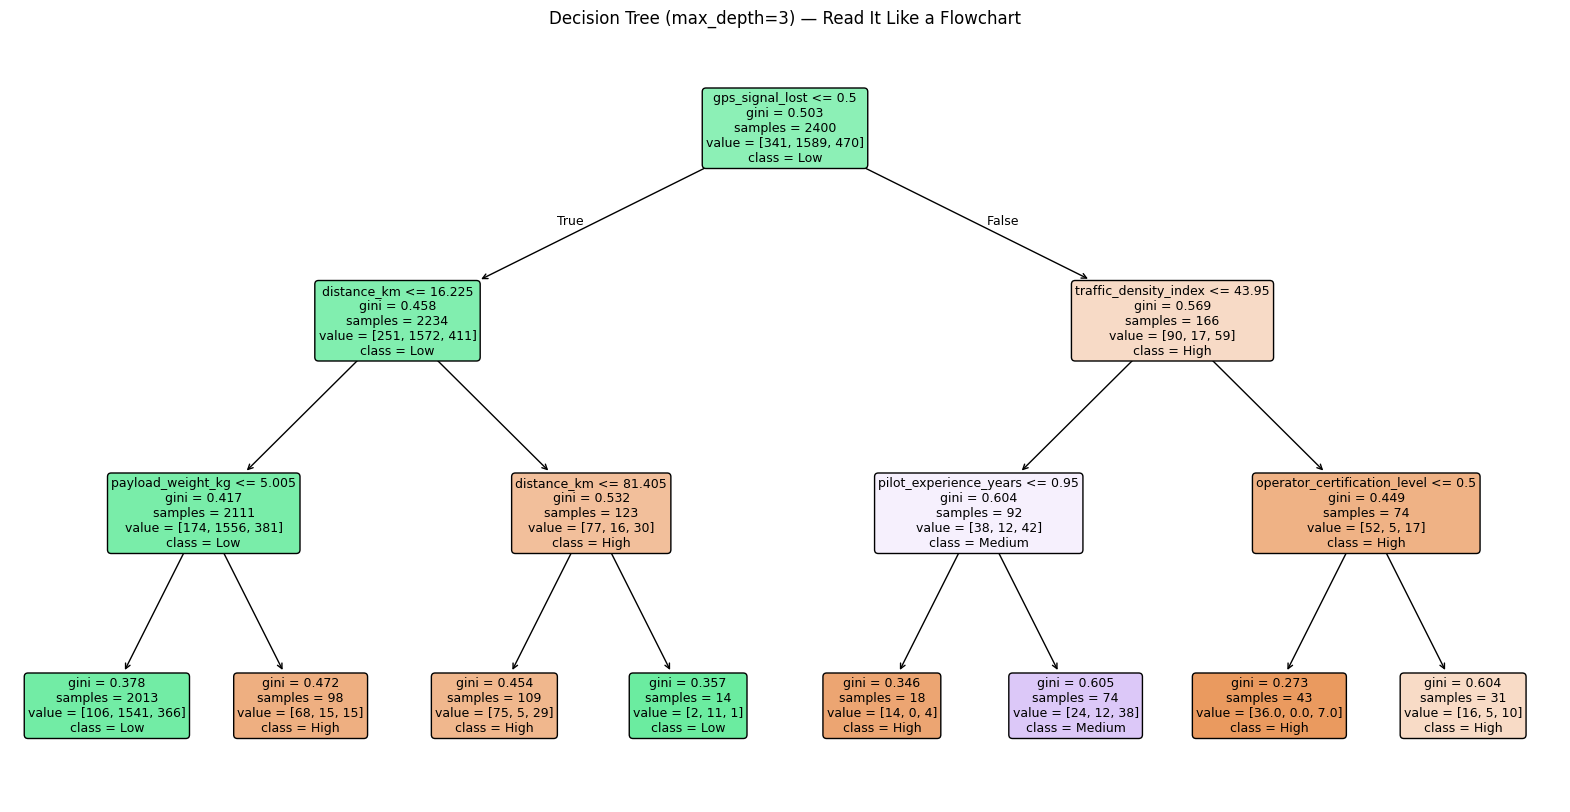

In [22]:

# Visualize the shallow tree — this is the whole point of using a small
# max_depth first: you can literally read the "questions" the model asks!
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_shallow,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
plt.title("Decision Tree (max_depth=3) — Read It Like a Flowchart")
plt.show()



Read this like a flowchart, top to bottom: at the **root** (top box), the
tree picked the single question that best separates Low/Medium/High risk.
Each box shows the split condition, the Gini impurity of that group, how
many training flights fall into it, and the class distribution. Follow any
path from top to a colored **leaf** — that path is a plain-English rule
your model learned, e.g. *"if GPS was not lost AND distance ≤ 14.9 AND
weather is not Stormy → Low risk."* No feature scaling, no encoding
gymnastics — just a series of readable thresholds.


In [ ]:

# Now let's compare a few DEPTHS to see the classic overfitting pattern
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
results = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_a = accuracy_score(y_train, dt.predict(X_train))
    test_a = accuracy_score(y_test, dt.predict(X_test))
    results.append({"max_depth": d if d is not None else "None (unlimited)", "train_accuracy": train_a, "test_accuracy": test_a})

depth_results = pd.DataFrame(results)
depth_results


,max_depth,train_accuracy,test_accuracy
0,1,0.692500,0.663333
1,2,0.719583,0.686667
2,3,0.749583,0.738333
3,4,0.767917,0.760000
4,5,0.775417,0.760000
5,6,0.799167,0.776667
6,8,0.844167,0.766667
7,10,0.880833,0.775000
8,15,0.965417,0.756667
9,None (unlimited),1.000000,0.730000


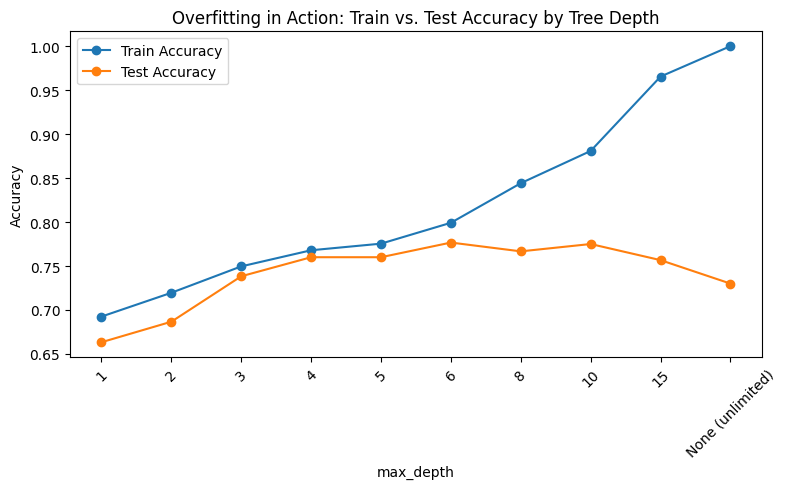

In [ ]:

# Plot train vs. test accuracy as depth increases — the classic overfitting curve
x_labels = [str(d) for d in depth_results["max_depth"]]
fig, ax = plt.subplots()
ax.plot(x_labels, depth_results["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(x_labels, depth_results["test_accuracy"], marker="o", label="Test Accuracy")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Overfitting in Action: Train vs. Test Accuracy by Tree Depth")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 📈 What just happened? (This IS overfitting.)

As `max_depth` grows, **training accuracy climbs toward 100%** — the tree
is literally memorizing individual training rows, including noise and
outliers. But **test accuracy plateaus, then flattens or even drops**. The
growing *gap* between the two lines is the textbook definition of
**overfitting**: a model that performs great on data it has already seen,
but doesn't generalize to new data.

This is exactly why we don't just let a Decision Tree grow to unlimited
depth — we control complexity using parameters like `max_depth` and
`min_samples_leaf`.


In [ ]:

# Experiment: min_samples_leaf (minimum flights required in a leaf node)
leaf_sizes = [1, 2, 5, 10, 20, 50, 100]
leaf_results = []

for leaf in leaf_sizes:
    dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=leaf, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_a = accuracy_score(y_train, dt.predict(X_train))
    test_a = accuracy_score(y_test, dt.predict(X_test))
    leaf_results.append({"min_samples_leaf": leaf, "train_accuracy": train_a, "test_accuracy": test_a})

pd.DataFrame(leaf_results)


,min_samples_leaf,train_accuracy,test_accuracy
0,1,0.844167,0.766667
1,2,0.837917,0.761667
2,5,0.821667,0.778333
3,10,0.817500,0.765000
4,20,0.789167,0.768333
5,50,0.765417,0.773333
6,100,0.750833,0.755000



`min_samples_leaf` forces every leaf to contain at least N training
examples — this directly prevents the tree from creating tiny, hyper-specific
leaves that exist only to capture a single outlier or noisy row. It's a
second, independent lever (alongside `max_depth`) for controlling
overfitting.


In [ ]:

# Experiment: criterion (gini vs entropy) -- do they actually differ much?
for criterion in ["gini", "entropy"]:
    dt = DecisionTreeClassifier(max_depth=6, criterion=criterion, random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_a = accuracy_score(y_train, dt.predict(X_train))
    test_a = accuracy_score(y_test, dt.predict(X_test))
    print(f"criterion={criterion:8s} -> Train accuracy: {train_a:.3f} | Test accuracy: {test_a:.3f}")


criterion=gini     -> Train accuracy: 0.799 | Test accuracy: 0.777
criterion=entropy  -> Train accuracy: 0.786 | Test accuracy: 0.760



In practice, **Gini and entropy usually produce very similar trees and
near-identical accuracy** — Gini is slightly cheaper to compute (no
logarithms), which is why it's scikit-learn's default. Don't lose sleep
over choosing between them.


In [ ]:

# Pick a reasonable, non-overfit Decision Tree to carry forward for the
# rest of the notebook (moderate depth + minimum leaf size)
dt_model = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=10, criterion="gini", random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_model.predict(X_test))
print(f"Final Decision Tree -> Train accuracy: {dt_train_acc:.3f} | Test accuracy: {dt_test_acc:.3f}")
print(f"(Compare to Logistic Regression -> Train: {train_acc_lr:.3f} | Test: {test_acc_lr:.3f})")


Final Decision Tree -> Train accuracy: 0.790 | Test accuracy: 0.772
(Compare to Logistic Regression -> Train: 0.711 | Test: 0.693)



## 10. Feature Importance

Decision Trees (and Random Forests) can report **feature importance**: how
much each feature contributed, on average, to reducing impurity across all
the splits that used it. Higher = the model relied on it more.

This is one of the most requested "beginner questions" — let's see if the
model's importances actually match the rules we built into the data!


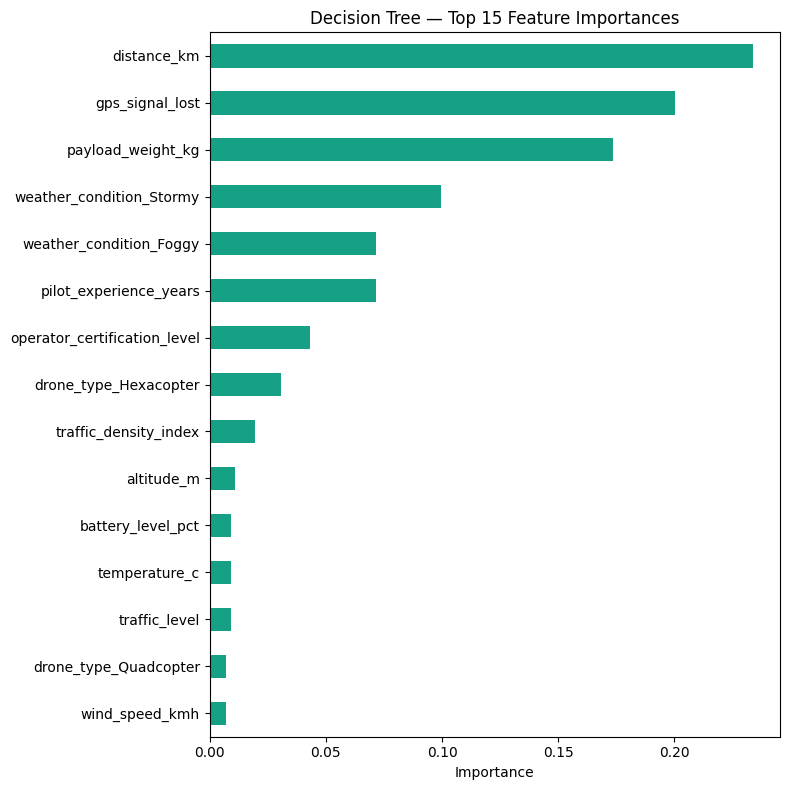

,0
distance_km,0.233824
gps_signal_lost,0.200323
payload_weight_kg,0.173488
weather_condition_Stormy,0.099778
weather_condition_Foggy,0.071516
pilot_experience_years,0.071490
operator_certification_level,0.042973
drone_type_Hexacopter,0.030641
traffic_density_index,0.019545
altitude_m,0.010828


In [ ]:

importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Decision Tree — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)



### 🔍 Interpreting this

Compare this ranking to the rules we deliberately built in Section 5:
`distance_km`, `battery_level_pct`, `temperature_c`, `gps_signal_lost`, and
weather-related features should rank highly — they're genuinely
informative. Meanwhile `altitude_m` and `sensor_reading` (our intentional
noise/weak-predictor columns) should rank low. If the model's importances
roughly agree with how we built the data, that's a great sign the model
learned real structure rather than noise.

> ⚠️ **A word of caution:** feature importance can shift noticeably if you
> change `random_state`, `max_depth`, or retrain on slightly different
> data (we'll prove this directly in the mini-exercises). Treat importance
> as a *useful signal*, not a precise, fixed ranking carved in stone.



## 11. Random Forests

### 🌲🌲🌲 The core idea

A single Decision Tree is powerful but a bit unstable — a small change in
the training data can produce a noticeably different tree (we'll prove
this in the mini-exercises too). A **Random Forest** fixes this by training
*many* trees and combining their opinions:

- **Bootstrap sampling**: each tree is trained on a random sample of the
  training data, drawn *with replacement* (so trees see overlapping, but
  not identical, data).
- **Bagging** (Bootstrap AGGregatING): the general technique of training
  many models on bootstrap samples and combining their predictions.
- **Random feature selection**: at each split, each tree only considers a
  random *subset* of features (controlled by `max_features`) — this
  deliberately decorrelates the trees so they don't all make the same
  mistakes.
- **Voting**: for classification, each tree "votes" for a class, and the
  forest predicts whichever class gets the most votes.
- **Why this reduces overfitting**: individual trees might overfit to
  quirks in their particular bootstrap sample, but those quirks are
  usually *different* across trees — averaging them out cancels much of
  that noise, while the genuine shared signal survives the vote.


In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5, max_features=0.7, random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Random Forest    -> Train accuracy: {rf_train_acc:.3f} | Test accuracy: {rf_test_acc:.3f}")
print(f"Decision Tree     -> Train accuracy: {dt_train_acc:.3f} | Test accuracy: {dt_test_acc:.3f}")
print(f"Logistic Regression -> Train accuracy: {train_acc_lr:.3f} | Test accuracy: {test_acc_lr:.3f}")


Random Forest    -> Train accuracy: 0.860 | Test accuracy: 0.782
Decision Tree     -> Train accuracy: 0.790 | Test accuracy: 0.772
Logistic Regression -> Train accuracy: 0.711 | Test accuracy: 0.693



Watch the **gap** between train and test accuracy for each model, and also
watch **test accuracy itself**. The clearest, most reliable way "bagging
reduces overfitting" shows up is when you compare a Random Forest to a
**deep, unconstrained** single tree (like the `max_depth=None` row back in
Section 9's overfitting curve) — that single tree's train/test gap is
huge, while a forest of similarly deep trees stays far more contained,
because errors that are specific to one bootstrap sample get out-voted by
the other trees.

Compared to the *already well-regularized* single tree we tuned above,
the two can look closer, or the forest's gap can even look a little larger
— that's normal. A shallow, carefully tuned single tree is a strong,
low-variance model in its own right. The forest's real advantages here are
**higher test accuracy** (more robust splits from averaging many
bootstrap samples) and **more stable feature importances**, not
"automatically zero overfitting."


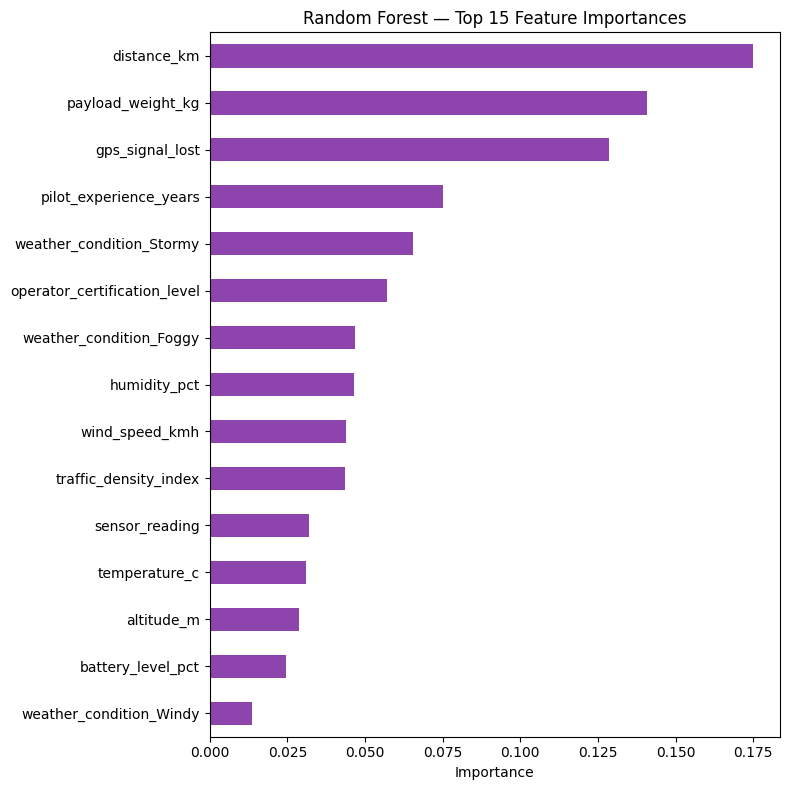

In [ ]:

# Feature importance from the Random Forest — compare to the single tree's ranking
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
rf_importances.head(15).sort_values().plot(kind="barh", ax=ax, color="#8e44ad")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()



Random Forest feature importances are typically **more stable** than a
single tree's (they're averaged across hundreds of trees, each seeing
different bootstrap samples), which is one more practical reason forests
are often preferred when importance rankings matter for business
decisions.



## 12. Circling Back: Do Trees Actually Care About Outliers?

We promised in Section 4 that we'd test this instead of just asserting it.
Let's train Logistic Regression, a Decision Tree, and a Random Forest on
**(a)** the full data (with outliers) and **(b)** the outlier-removed data,
and directly compare test accuracy.


In [ ]:

def prepare_features(raw_df):
    # Apply the same encoding/cleaning pipeline used above to any dataframe.
    d = raw_df.drop(columns=["flight_id", "risk_score_hidden"]).copy()
    for c in bool_cols:
        d[c] = d[c].astype(int)
    d["operator_certification_level"] = d["operator_certification_level"].map(cert_order)
    d["traffic_level"] = d["traffic_level"].map(traffic_order)
    d = pd.get_dummies(d, columns=nominal_cols, drop_first=True)
    for col in ["humidity_pct", "pilot_experience_years", "sensor_reading"]:
        d[col] = d[col].fillna(d[col].median())
    d["risk_level_encoded"] = target_encoder.transform(d["risk_level"])
    # Make sure columns match the original training columns exactly
    d = d.reindex(columns=list(feature_cols) + ["risk_level_encoded", "risk_level"], fill_value=0)
    return d

def run_comparison(raw_df, label):
    d = prepare_features(raw_df)
    Xd, yd = d[feature_cols], d["risk_level_encoded"]
    Xd_train, Xd_test, yd_train, yd_test = train_test_split(
        Xd, yd, test_size=0.2, random_state=RANDOM_STATE, stratify=yd
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "Decision Tree": DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE),
    }

    rows = []
    for name, model in models.items():
        model.fit(Xd_train, yd_train)
        acc = accuracy_score(yd_test, model.predict(Xd_test))
        rows.append({"dataset": label, "model": name, "test_accuracy": round(acc, 3)})
    return rows

rows = run_comparison(df, "Full data (with outliers)")
rows += run_comparison(df_clean, "Outliers removed")
outlier_comparison = pd.DataFrame(rows).pivot(index="model", columns="dataset", values="test_accuracy")
outlier_comparison


dataset,Full data (with outliers),Outliers removed
model,,
Decision Tree,0.772,0.736
Logistic Regression,0.693,0.740
Random Forest,0.738,0.748



### 🧠 What do you see?

Look at the actual numbers in your table rather than assuming a rule of
thumb — this dataset makes an important, slightly humbling point.

You'll likely see **Logistic Regression's accuracy change the most**
after outliers are removed (linear models fit a line/plane that every
point — including extreme ones — pulls on), and **Random Forest change
the least** of the three, because averaging many trees smooths out the
influence any single unusual row can have on the final vote. That's the
measurable version of "tree ensembles are robust to outliers."

A single **Decision Tree can still shift noticeably**, though — and here's
the important nuance: our IQR method flagged about **18% of all rows** as
outliers in *some* column, which is far more than just the handful of
synthetic sensor glitches and typos we deliberately injected. Features
like `distance_km`, `wind_speed_kmh`, and `pilot_experience_years` are
naturally right-skewed (most flights are short/calm/junior-piloted, with a
realistic long tail of longer/windier/senior-piloted ones) — IQR
mechanically flags a lot of that natural tail as "outliers" too, even
though it's genuine, informative data. Blindly deleting everything IQR
flags throws away real signal, which is exactly why a single tree (with
fewer rows and less signal to split on) can get *worse*, not better, after
"cleaning."

**The takeaway isn't "trees are immune to outliers, full stop."** It's:
(1) ensembling adds real robustness on top of what trees already have,
and (2) an automated outlier *rule* is not the same as an outlier
*judgment* — always look at what got flagged before deleting it. Some of
these outliers really were impossible data-entry errors (>100% battery,
sub-zero readings in a city that rarely freezes) worth fixing at the
source; many others were just honest long-tail data worth keeping.



## 13. Random Forest Hyperparameter Experiments

Random Forests have several knobs. Let's experiment with the big ones and
record what happens — this is exactly the kind of experimentation you
should get comfortable running on any new dataset.


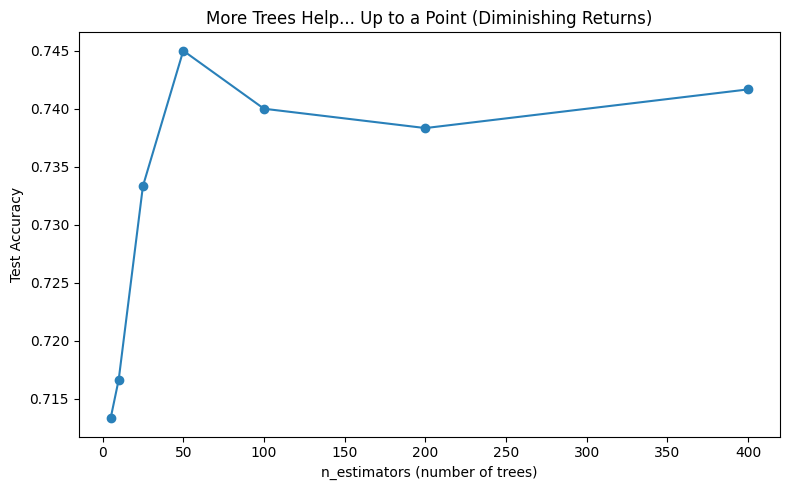

,n_estimators,test_accuracy
0,5,0.713333
1,10,0.716667
2,25,0.733333
3,50,0.745000
4,100,0.740000
5,200,0.738333
6,400,0.741667


In [ ]:

# n_estimators: how many trees in the forest?
n_estimators_list = [5, 10, 25, 50, 100, 200, 400]
n_est_results = []
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    n_est_results.append({"n_estimators": n, "test_accuracy": acc})

n_est_df = pd.DataFrame(n_est_results)
fig, ax = plt.subplots()
ax.plot(n_est_df["n_estimators"], n_est_df["test_accuracy"], marker="o", color="#2980b9")
ax.set_xlabel("n_estimators (number of trees)")
ax.set_ylabel("Test Accuracy")
ax.set_title("More Trees Help... Up to a Point (Diminishing Returns)")
plt.tight_layout()
plt.show()
n_est_df


In [ ]:

# max_features: how many features each split is allowed to consider
for mf in ["sqrt", "log2", None, 0.5]:
    rf = RandomForestClassifier(n_estimators=150, max_depth=6, min_samples_leaf=10,
                                  max_features=mf, random_state=RANDOM_STATE)
    rf.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf.predict(X_test))
    print(f"max_features={str(mf):6s} -> Test accuracy: {acc:.3f}")


max_features=sqrt   -> Test accuracy: 0.735
max_features=log2   -> Test accuracy: 0.733
max_features=None   -> Test accuracy: 0.765
max_features=0.5    -> Test accuracy: 0.757


In [ ]:

# min_samples_split & criterion together (a small grid)
grid_results = []
for min_split in [2, 10, 30]:
    for criterion in ["gini", "entropy"]:
        rf = RandomForestClassifier(
            n_estimators=150, max_depth=6, min_samples_split=min_split,
            criterion=criterion, random_state=RANDOM_STATE
        )
        rf.fit(X_train, y_train)
        acc = accuracy_score(y_test, rf.predict(X_test))
        grid_results.append({"min_samples_split": min_split, "criterion": criterion, "test_accuracy": round(acc, 3)})

pd.DataFrame(grid_results)


,min_samples_split,criterion,test_accuracy
0,2,gini,0.750
1,2,entropy,0.750
2,10,gini,0.748
3,10,entropy,0.745
4,30,gini,0.743
5,30,entropy,0.742



### 📝 Observations to discuss as a class

- Accuracy usually improves quickly as `n_estimators` grows, then
  **plateaus** — more trees cost more computation for smaller and smaller
  gains. There's rarely a reason to use thousands of trees on a dataset
  this size.
- `max_features` controls how *decorrelated* the trees are from each
  other — too low, and individual trees get weak; too high (all features,
  every split), and trees become more similar to each other, edging back
  toward "a bunch of copies of one Decision Tree."
- `min_samples_split`/`min_samples_leaf` and `criterion` interact with
  `max_depth` the same way they did for a single tree — they're all levers
  on the same underlying overfitting/underfitting trade-off.



## 14. Model Evaluation, Explained Simply

Accuracy alone can be misleading — especially on an **imbalanced** target
like ours (remember, "Low" risk is the majority class). Here's what each
metric actually tells you, in plain language:

- **Accuracy**: % of all predictions that were correct. Simple, but can
  hide poor performance on minority classes.
- **Precision** (per class): *"Of all the flights I predicted as X, how
  many actually were X?"* High precision = few false alarms for that class.
- **Recall** (per class): *"Of all the flights that were actually X, how
  many did I correctly catch?"* High recall = few missed cases.
- **F1-score**: the harmonic mean of precision and recall — a single
  number that balances both. Useful when you care about both false alarms
  and missed cases.
- **Confusion Matrix**: a full table of predicted vs. actual classes — the
  most detailed and honest way to see *where* a model gets confused
  (e.g., mixing up "Medium" and "High" risk, which is a much bigger deal
  for a drone company than mixing up "Low" and "Medium").
- **ROC-AUC**: measures how well the model ranks/ separates classes across
  *all* possible decision thresholds, not just the default one. For
  multi-class problems we compute it one-vs-rest, per class.


===== Logistic Regression =====
Accuracy:  0.693
Precision (macro avg): 0.544
Recall (macro avg):    0.440
F1-score (macro avg):  0.449
ROC-AUC (macro, one-vs-rest): 0.756

              precision    recall  f1-score   support

        High       0.31      0.16      0.22        85
         Low       0.74      0.95      0.83       397
      Medium       0.59      0.20      0.30       118

    accuracy                           0.69       600
   macro avg       0.54      0.44      0.45       600
weighted avg       0.65      0.69      0.64       600



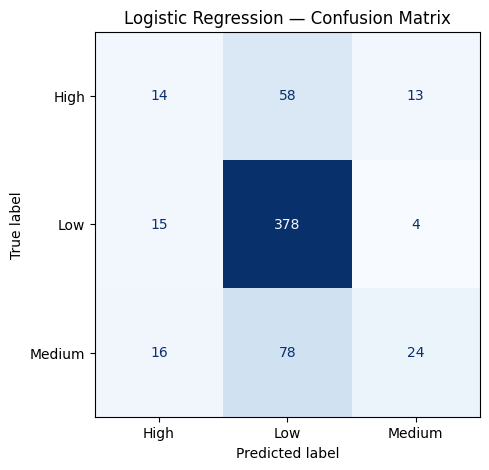

===== Decision Tree =====
Accuracy:  0.772
Precision (macro avg): 0.681
Recall (macro avg):    0.615
F1-score (macro avg):  0.628
ROC-AUC (macro, one-vs-rest): 0.809

              precision    recall  f1-score   support

        High       0.68      0.64      0.66        85
         Low       0.81      0.95      0.88       397
      Medium       0.55      0.25      0.35       118

    accuracy                           0.77       600
   macro avg       0.68      0.61      0.63       600
weighted avg       0.74      0.77      0.74       600



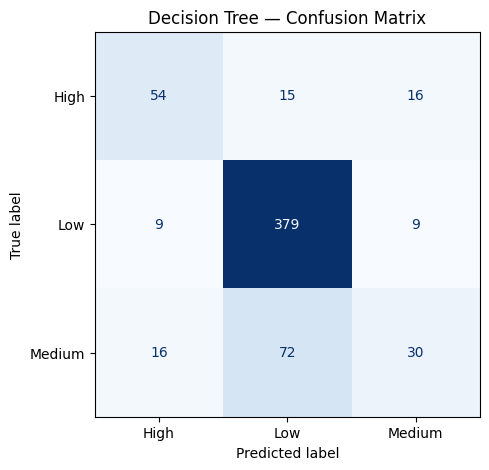

===== Random Forest =====
Accuracy:  0.782
Precision (macro avg): 0.691
Recall (macro avg):    0.639
F1-score (macro avg):  0.648
ROC-AUC (macro, one-vs-rest): 0.881

              precision    recall  f1-score   support

        High       0.69      0.69      0.69        85
         Low       0.83      0.95      0.89       397
      Medium       0.55      0.27      0.36       118

    accuracy                           0.78       600
   macro avg       0.69      0.64      0.65       600
weighted avg       0.75      0.78      0.76       600



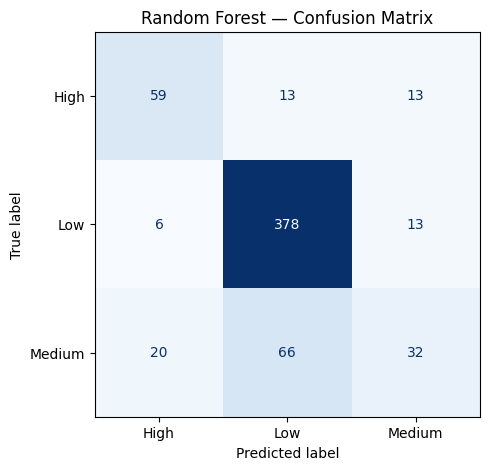

In [ ]:

def evaluate_model(model, X_te, y_te, name):
    preds = model.predict(X_te)
    proba = model.predict_proba(X_te)

    acc = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average="macro")
    rec = recall_score(y_te, preds, average="macro")
    f1 = f1_score(y_te, preds, average="macro")
    try:
        auc = roc_auc_score(y_te, proba, multi_class="ovr", average="macro")
    except ValueError:
        auc = np.nan

    print(f"===== {name} =====")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision (macro avg): {prec:.3f}")
    print(f"Recall (macro avg):    {rec:.3f}")
    print(f"F1-score (macro avg):  {f1:.3f}")
    print(f"ROC-AUC (macro, one-vs-rest): {auc:.3f}")
    print()
    print(classification_report(y_te, preds, target_names=target_encoder.classes_))

    cm = confusion_matrix(y_te, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix")
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

eval_rows = []
eval_rows.append(evaluate_model(log_reg, X_test, y_test, "Logistic Regression"))
eval_rows.append(evaluate_model(dt_model, X_test, y_test, "Decision Tree"))
eval_rows.append(evaluate_model(rf_model, X_test, y_test, "Random Forest"))



## 15. Side-by-Side Comparison

Let's pull everything together into one summary table.


In [ ]:

import time

def time_fit(model, X_tr, y_tr):
    start = time.time()
    model.fit(X_tr, y_tr)
    return time.time() - start

# Re-fit fresh copies purely to get a fair timing comparison
lr_time = time_fit(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), X_train, y_train)
dt_time = time_fit(DecisionTreeClassifier(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE), X_train, y_train)
rf_time = time_fit(RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5, max_features=0.7, random_state=RANDOM_STATE), X_train, y_train)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Train Accuracy": [train_acc_lr, dt_train_acc, rf_train_acc],
    "Test Accuracy": [test_acc_lr, dt_test_acc, rf_test_acc],
    "Overfitting Gap (Train-Test)": [
        train_acc_lr - test_acc_lr, dt_train_acc - dt_test_acc, rf_train_acc - rf_test_acc
    ],
    "Interpretability": ["High (coefficients)", "High (readable flowchart)", "Medium (importances, not a single flowchart)"],
    "Training Time (s)": [lr_time, dt_time, rf_time],
    "Robust to Outliers?": ["Lower", "Higher", "Higher"],
    "Handles Non-Linearity?": ["Poor (linear boundary only)", "Good", "Best (usually)"],
})
comparison.round(4)


,Model,Train Accuracy,Test Accuracy,Overfitting Gap (Train-Test),Interpretability,Training Time (s),Robust to Outliers?,Handles Non-Linearity?
0,Logistic Regression,0.7113,0.6933,0.0179,High (coefficients),2.0246,Lower,Poor (linear boundary only)
1,Decision Tree,0.7900,0.7717,0.0183,High (readable flowchart),0.0315,Higher,Good
2,Random Forest,0.8604,0.7817,0.0788,"Medium (importances, not a single flowchart)",5.9472,Higher,Best (usually)



Use this table as the anchor for a class discussion — it's the single
best summary of everything we tested today.



## 16. Reflection Questions

Discuss these with a partner, then write short answers in the markdown
cell below (double-click to edit).

1. Why did Random Forest perform better (or not!) than a single Decision
   Tree on this dataset? Point to specific evidence from the notebook.
2. Did removing outliers actually improve performance? For which model(s)?
   Was the effect what you expected after Section 4/12?
3. Which features had the highest importance? Do they match the nonlinear
   rules we visualized in Section 5? Which features were consistently
   *unimportant* — does that match how we built the data?
4. Would Logistic Regression ever be the *better* choice, even though it
   scored lower here? Think about interpretability, training time, and
   what happens with much smaller datasets.
5. Look back at the overfitting curve in Section 9. If you were deploying
   this model for a real drone company, which `max_depth` would you pick,
   and why — and how would that decision change if a false "Low risk"
   prediction could cause a real safety incident?

### ✍️ Your answers

*(Double-click this cell to edit and write your answers here.)*

1.
2.
3.
4.
5.



## 17. Mini Exercises

Work through these directly in the notebook. Each one only needs small
edits to code you've already seen above — that's intentional. Use new
cells below each prompt so your original results stay visible for
comparison.



### Exercise 1 — Change `max_depth`
Retrain a Decision Tree with `max_depth=2` and again with `max_depth=20`.
Compare train/test accuracy to the `max_depth=6` model above. Which one
would you actually ship to production, and why?


In [ ]:

# Exercise 1 — your code here
# dt_ex1 = DecisionTreeClassifier(max_depth=___, random_state=RANDOM_STATE)
# dt_ex1.fit(X_train, y_train)
# ...



### Exercise 2 — Remove one feature and retrain
Drop the single most important feature (check your feature importance
ranking from Section 10) from `X_train`/`X_test`, retrain the Random
Forest, and compare accuracy. How much did performance drop? What does
that tell you about how "essential" that one feature really is?


In [ ]:

# Exercise 2 — your code here
# top_feature = rf_importances.index[0]
# X_train_ex2 = X_train.drop(columns=[top_feature])
# X_test_ex2 = X_test.drop(columns=[top_feature])
# ...



### Exercise 3 — Increase outliers, then retrain
Make a copy of `df`, artificially inject even MORE extreme
`battery_level_pct` outliers (e.g., set 5% of rows to random values
between 150–300), rerun the encoding pipeline (`prepare_features`), and
retrain Logistic Regression vs. Random Forest. Does the gap between them
grow?


In [ ]:

# Exercise 3 — your code here
# df_more_outliers = df.copy()
# ...



### Exercise 4 — Increase class imbalance, then retrain
Create a version of the training data with even fewer "High" risk
examples (e.g., randomly drop 70% of High-risk rows from `X_train`/`y_train`
only — never touch the test set). Retrain and re-evaluate using
`classification_report`. What happens specifically to **recall** on the
"High" class? Why does that matter more for this business than accuracy
dropping slightly?


In [ ]:

# Exercise 4 — your code here



### Exercise 5 — Predict on five manually created examples
Create five new "flights" by hand (as a small DataFrame matching the
`feature_cols` structure) representing scenarios you design — e.g., a
calm short urban trip, a long hot-day low-battery trip, a stormy night
restricted-zone trip. Use `rf_model.predict()` and `rf_model.predict_proba()`
on them. Do the predictions match your intuition? If not, why might that be?


In [ ]:

# Exercise 5 — your code here
# Tip: start from X_test.iloc[[0]].copy() and edit the values, so your
# manual example already has the right columns in the right order.
# example = X_test.iloc[[0]].copy()
# example["distance_km"] = 25
# example["battery_level_pct"] = 15
# example["temperature_c"] = 42
# rf_model.predict(example), rf_model.predict_proba(example)



## 18. Challenge Activity — Beat the Baseline by 3%+

**Goal:** improve the Random Forest's **test accuracy** by at least **3
percentage points** above the baseline trained in Section 11
(`rf_test_acc`, printed above).

You're free to try anything covered today (or earlier sessions):
hyperparameter tuning, feature engineering (e.g., create your own
interaction feature like `is_hot_and_low_battery`), different outlier
handling, or rebalancing the training classes.

**You must document, in the markdown cell below:**
1. **What** you changed
2. **Why** you thought it would help
3. **What actually happened** (with the before/after accuracy numbers)

This mirrors real ML work — most gains come from thoughtful iteration, not
one lucky hyperparameter.


In [ ]:

# Challenge Activity — your experimentation code here
print(f"Baseline Random Forest test accuracy to beat: {rf_test_acc:.3f} (target: {rf_test_acc + 0.03:.3f}+)")

# your_model = RandomForestClassifier(...)
# your_model.fit(X_train_modified, y_train_modified)
# new_acc = accuracy_score(y_test, your_model.predict(X_test_modified))
# print(f"New test accuracy: {new_acc:.3f}")


Baseline Random Forest test accuracy to beat: 0.782 (target: 0.812+)



### ✍️ Challenge write-up

*(Double-click to edit)*

**What I changed:**

**Why I thought it would help:**

**Result (before → after):**

---

## 🎉 Session 4 Wrap-Up

Today you moved from theory to evidence: you built a dataset with
outliers and nonlinearity on purpose, watched a linear model struggle with
it, and watched Decision Trees and Random Forests handle it more
gracefully — while also seeing trees overfit when left unchecked. Bring
your Challenge Activity results to next session, where we'll build on
these same tree-based ideas with boosting methods.
